<h1 style="text-align: center;"> Anticipez les besoins en consommation de bâtiments</h1>

$\Large \textbf{Sommaire}$

---

<ul style="list-style-type:none;">
  <li>Import des modules</li>

  <li>1. Analyse exploratoire
    <ul style="list-style-type:none;">
      <li>1.1. Chargement des données</li>
      <li>1.2. Sélection des bâtiments pertinents</li>
      <li>1.3. Sélection de la variable cible (Target)</li>
      <li>1.4. Étude et nettoyage 
        <ul style="list-style-type:none;">
          <li>1.4.1. DefaultData, outliers et ComplianceStatus</li>
          <li>1.4.2. Outliers sur la cible : méthode IQR</li>
          <li>1.4.3. Localisation</li>
          <li>1.4.4. Année de construction</li>
          <li>1.4.5. Grandeurs physiques des biens immobiliers</li>
          <li>1.4.6. Type de bien </li>            
        </ul>
      </li>
    </ul>
  </li>

  <li>2. Préparation des features pour la modélisation
    <ul style="list-style-type:none;">
      <li>2.1. Binarisation des colonnes électricité et gaz</li>
      <li>2.2. Numérisation de la localisation (quartier – OneHotEncoder)</li>
      <li>2.3. Numérisation du type de bien (OneHotEncoder)</li>
    </ul>
  </li>

  <li>3. Comparaison de modèles supervisés
    <ul style="list-style-type:none;">
      <li>3.1. Régression linéaire</li>
      <li>3.2. Forêt aléatoire</li>
      <li>3.3. SVR</li>
    </ul>
  </li>

  <li>4. Optimisation et interprétation du modèle
    <ul style="list-style-type:none;">
      <li>4.1. GridSearch</li>
      <li>4.2. Feature importance</li>
    </ul>
  </li>

</ul>

---

<h2> Import des modules  </h2> 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [2]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
    KFold
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

from sklearn.pipeline import Pipeline

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


<h2> 1. Analyse exploratoire </h2> 

--- 




<h3> 1.1. Chargement des données </h3> 

<p> Dans cette sous-section, nous allons :
    
<ol> 
    - Charger le fichier csv et visualiser les $5$ premières lignes</br> 
    - Obtenir des informations basiques </br> 
    - Supprimer certaines colonnes  </br> 
</ol>
</p> 

In [3]:
building_consumption = pd.read_csv('Data/2016_Building_Energy_Benchmarking.csv')

# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [4]:
L_avant, C_avant = building_consumption.shape


print(f'\n Il y a {L_avant} lignes et {C_avant} colonnes. \n')


 Il y a 3376 lignes et 46 colonnes. 



In [5]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

<p> Nous allons nettoyer le dataset afin de garder uniquement les colonnes pertinantes.  Nous pouvons supprimer:

    - la colonne OSEBuildingID qui est arbitraire 
    - la colonne "Comments" qui est vide
    - la colonne YearsENERGYSTARCertified qui 'est pas suffisement remplis 
    - La colonne ENERGYSTARScore quantife la performance energetique, pour éviter un data leakage  on doit la supprimer
    
    
</p> 

In [6]:
print(f'{building_consumption[['DataYear','City','State']].value_counts()}')

DataYear  City     State
2016      Seattle  WA       3376
Name: count, dtype: int64


<p> 
Les colonnes 'DataYear' (2016) ,  'City'  (Seattle) et 'State' (WA)  n'étant composé que d'une valeur identique pour tous les biens, peuvent également être supprimé.  
   

On souhaite predir uniquement la consomation, on peut donc supprimer les collones relatives aux emissions :
- 'TotalGHGEmissions'
-  'GHGEmissionsIntensity'.

On retire également l'Address et TaxParcelIdentificationNumber car trop de valeurs pour être utilisé comme target

</p>


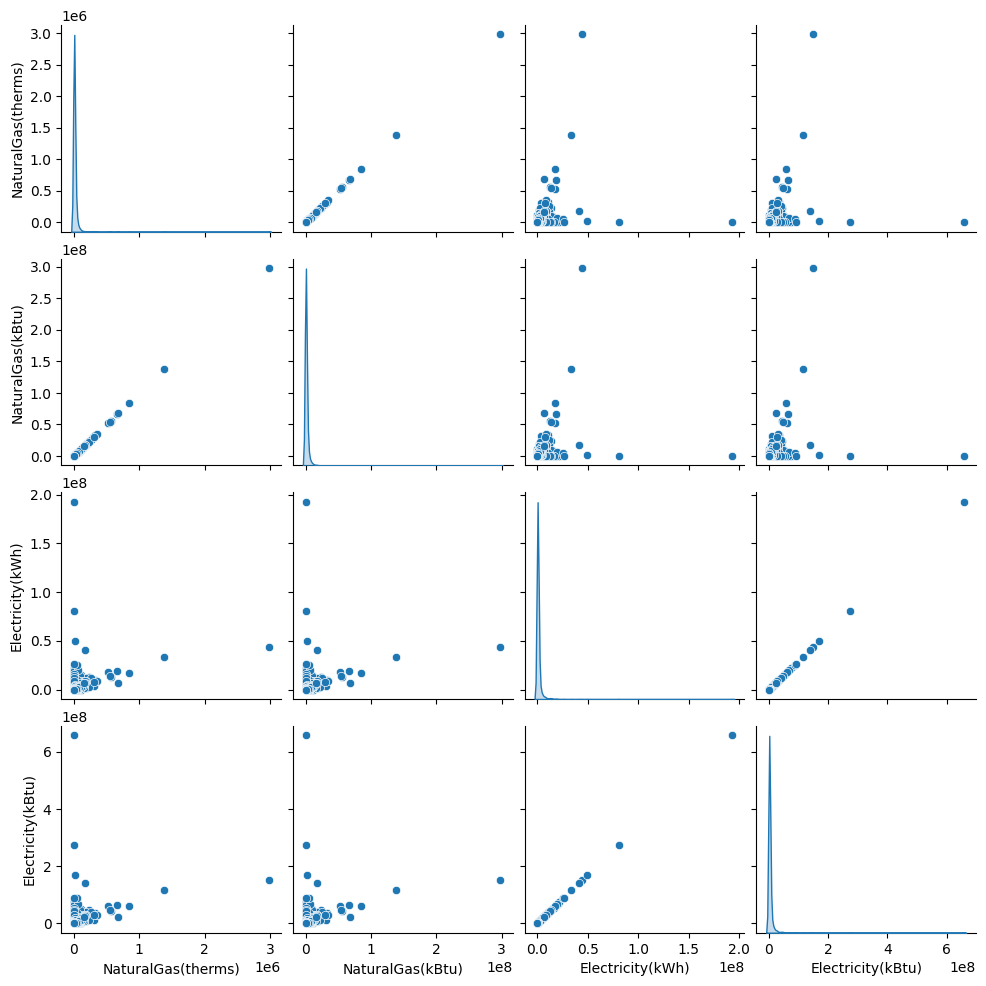

In [7]:
col_quanti=['NaturalGas(therms)','NaturalGas(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)']
sns.pairplot(building_consumption[col_quanti], diag_kind='kde')

<p> On observe une forte correlation entre

-  'NaturalGas(therms)' et 'NaturalGas(kBtu)'  
    
-  'Electricity(kWh)' et 'Electricity(kBtu)'. 
    
En effet le passage de l'une vers l'autre n'est qu'une conversion. On garde uniquement les energies en Kbtu NaturalGas(therms) et Electricity(kWh) sont à supprimer

</p> 

In [8]:
a_supp=['OSEBuildingID','Comments', 'DataYear','City',
        'State','Address','YearsENERGYSTARCertified','NaturalGas(therms)','ENERGYSTARScore', 'TaxParcelIdentificationNumber',
        'Electricity(kWh)','TotalGHGEmissions','GHGEmissionsIntensity']
building_consumption=building_consumption.drop(a_supp,axis=1)

building_consumption = building_consumption.drop_duplicates()


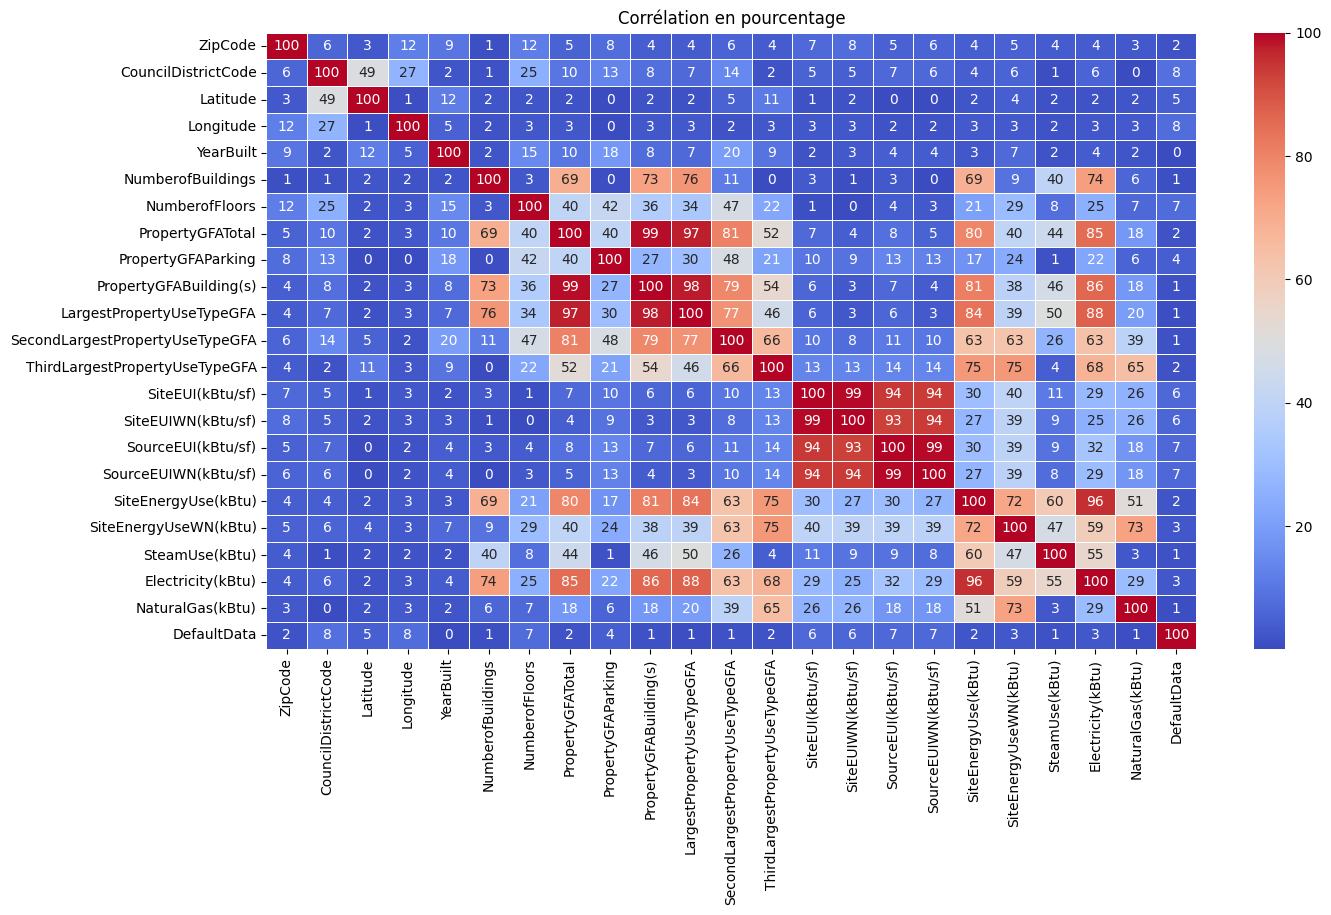

In [9]:
corr_matrix = building_consumption.corr(numeric_only=True)

# Taille de la figure
plt.figure(figsize=(15, 8))

# Création de la heatmap
sns.heatmap(
    np.abs(corr_matrix*100),
    annot=True,        
    cmap="coolwarm",   
    fmt=".0f",         
    linewidths=0.5     
)

plt.title("Corrélation en pourcentage")
plt.show()

<h3> 1.2. Sélection des bâtiments pertinents</h3> 

<p>
    Pour selectioner uniquement les batiments non résidentiel nous devons analyser les colonnes 'BuildingType' et 'PrimaryPropertyType'. 
    On pourra ensuite supprimer 'BuildingType' et 'PropertyName' car elle ne seront plus utiles.
</p> 

In [10]:
#On regarde les types de batiments
building_consumption['BuildingType'].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [11]:
#On souhaite se limiter aux batiments non residentiels. On peut donc retirer  Multifamily LR (1-4)  Multifamily MR (5-9)  et 
# et Multifamily HR (10+)
a_supp=['Multifamily LR (1-4)', 'Multifamily MR (5-9)' , 'Multifamily HR (10+)']
building_consumption=building_consumption[~building_consumption['BuildingType'].isin(a_supp)]

In [12]:
#On regarde le details sur PrimaryPropertyType
building_consumption['PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    292
Other                          250
Warehouse                      187
Large Office                   173
K-12 School                    139
Mixed Use Property             114
Retail Store                    91
Hotel                           76
Worship Facility                71
Distribution Center             53
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Restaurant                      12
Refrigerated Warehouse          12
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             3
Office                           3
Name: count, dtype: int64

In [13]:
#On retire les Low-Rise Multifamily   et Residence Hall
a_supp=['Low-Rise Multifamily','Residence Hall']
building_consumption=building_consumption[~building_consumption['PrimaryPropertyType'].isin(a_supp)]
a_supp=['BuildingType','PropertyName']
building_consumption=building_consumption.drop(a_supp,axis=1)



In [14]:
L_apr, C_apr = building_consumption.shape

print(f" \n Initial {L_avant} lignes et {C_avant} colonnes. \n Actuel {L_apr} lignes et {C_apr} colonnes. \n")

 
 Initial 3376 lignes et 46 colonnes. 
 Actuel 1644 lignes et 31 colonnes. 



<h3> 1.3. Sélection de la variable cible (Target)</h3> 

<p> Nous devons désormais choisir une target parmi les colonnes suivante:
       
     - SiteEUI(kBtu/sf) :    quantité annuelle totale d'énergie consommée par le site, telle qu'indiquée sur les factures d'électricité normalisé par la surface.
    
     - SiteEUIWN(kBtu/sf) :  correspond à SiteEUI(kBtu/sf) ajustée selon des conditions météorologiques moyennes sur 30 ans.
            
     - SourceEUI(kBtu/sf)  :  quantité d’énergie totale nécessaire pour faire fonctionner le bâtiment, en incluant les pertes liées à la production et au transport de l’énergie.         
     
     - SourceEUIWN(kBtu/sf) : correspond à SourceEUI(kBtu/sf) ajustée selon des conditions météorologiques moyennes sur 30 ans.       
     
     - SiteEnergyUse(kBtu)  :  quantité annuelle totale d'énergie consommée par le site.        
     
     - SiteEnergyUseWN(kBtu) :  correspond à SiteEnergyUse(kBtu)  ajustée selon des conditions météorologiques moyennes sur 30 ans.             
     
     - SteamUse(kBtu)    :  indique la quantité totale d’énergie consommée sous forme de vapeur.      

On souhaite estimer la consomation energetique des batiments. Il faudra donc avoir une information de l'energie réel consommé, facturé ("SITE") et normalisé par la surface (kBtu/sf). 

on peux donc retirer  SourceEUI(kBtu/sf) , SourceEUIWN(kBtu/sf)  SiteEnergyUse(kBtu),  SiteEnergyUseWN(kBtu)  et SteamUse(kBtu) 

</p> 

In [15]:

a_supp=['SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)' , 'SiteEnergyUse(kBtu)',  'SiteEnergyUseWN(kBtu)' , 'SteamUse(kBtu)'  ]
building_consumption=building_consumption.drop(a_supp,axis=1)



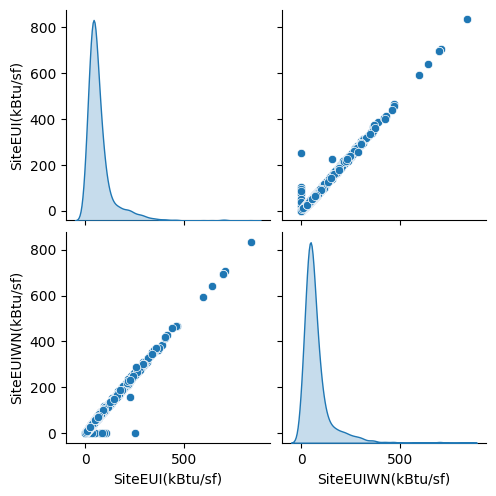

In [16]:

sns.pairplot(building_consumption[['SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)']], diag_kind='kde')


<p> Les grandeures SiteEUI(kBtu/sf)  et SiteEUIWN(kBtu/sf) étant fortement correlé, nous allons garder celle qui contient le plus de valeur à savoir SiteEUIWN(kBtu/sf). 
</p> 

In [17]:
#On peux supprimer'SiteEUI(kBtu/sf)'

a_supp=['SiteEUI(kBtu/sf)'  ]
building_consumption=building_consumption.drop(a_supp,axis=1)


In [18]:
L_apr, C_apr = building_consumption.shape

print(f" \n Initial {L_avant} lignes et {C_avant} colonnes. \n Actuel {L_apr} lignes et {C_apr} colonnes. \n")

 
 Initial 3376 lignes et 46 colonnes. 
 Actuel 1644 lignes et 25 colonnes. 



<h3> 1.4. Étude et nettoyage </h3> 

In [19]:
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1644 entries, 0 to 3375
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   PrimaryPropertyType              1644 non-null   object 
 1   ZipCode                          1628 non-null   float64
 2   CouncilDistrictCode              1644 non-null   int64  
 3   Neighborhood                     1644 non-null   object 
 4   Latitude                         1644 non-null   float64
 5   Longitude                        1644 non-null   float64
 6   YearBuilt                        1644 non-null   int64  
 7   NumberofBuildings                1642 non-null   float64
 8   NumberofFloors                   1644 non-null   int64  
 9   PropertyGFATotal                 1644 non-null   int64  
 10  PropertyGFAParking               1644 non-null   int64  
 11  PropertyGFABuilding(s)           1644 non-null   int64  
 12  ListOfAllPropertyUseTypes

<h4> 1.4.1. DefaultData, outliers et ComplianceStatus </h4> 

<p> Ces colonnes nous permette de supprimer des biens immobiliers non pertinant. On commence par supprimer les Outliers via la colonne Outlier puis on verifie les info fourni par ComplianceStatus.
   
ComplianceStatus indique si le proprietaire à fournis les informations. On pourra supprimer :

- Error - Correct Default Data  
- Non-Compliant                
- Missing Data

On explore la colonne DefaultData pour montrer que les valeurs 'True' de DefaultData  sont associé à 'Error - Correct Default Data' de 'ComplianceStatus'.

On supprime ensuite également les outlier et la collonne Outlier

On pourra donc supprimer DefaultData, 'ComplianceStatus'  et Outlier

</p>


In [20]:
building_consumption['ComplianceStatus'].value_counts()

ComplianceStatus
Compliant                       1525
Error - Correct Default Data      88
Non-Compliant                     17
Missing Data                      14
Name: count, dtype: int64

In [21]:
a_supp=['Error - Correct Default Data','Non-Compliant','Missing Data']
building_consumption=building_consumption[~building_consumption['ComplianceStatus'].isin(a_supp)]

In [22]:
building_consumption=building_consumption[building_consumption['Outlier'].isna()]
a_supp=['Outlier','ComplianceStatus', 'DefaultData' ]
building_consumption=building_consumption.drop(a_supp,axis=1)

In [23]:
L_apr, C_apr = building_consumption.shape

print(f" \n Initial {L_avant} lignes et {C_avant} colonnes. \n Actuel {L_apr} lignes et {C_apr} colonnes. \n")

 
 Initial 3376 lignes et 46 colonnes. 
 Actuel 1525 lignes et 22 colonnes. 



<h4> 1.4.2. Outliers sur la cible : méthode IQR </h4> 

<p> On s'interesse desormais à la cible, on souhaite utiliser la methode IQR pour supprimer les Outliers.

</p>

In [24]:
#Etude statistique de la cible 
building_consumption['SiteEUIWN(kBtu/sf)'].describe()

count    1524.000000
mean       77.794095
std        76.698604
min         0.000000
25%        37.099998
50%        56.200001
75%        88.350002
max       834.400024
Name: SiteEUIWN(kBtu/sf), dtype: float64

<Axes: xlabel='SiteEUIWN(kBtu/sf)', ylabel='Density'>

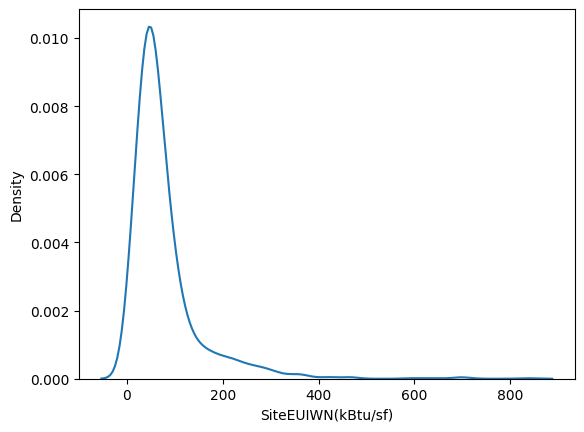

In [25]:
sns.kdeplot(building_consumption['SiteEUIWN(kBtu/sf)'])

In [26]:
#On va retirer les outliers en utilisant la methode IQR

Q1 = building_consumption['SiteEUIWN(kBtu/sf)'].quantile(0.25)
Q3 = building_consumption['SiteEUIWN(kBtu/sf)'].quantile(0.75)
IQR = Q3 - Q1

building_consumption=building_consumption[(building_consumption['SiteEUIWN(kBtu/sf)'] >= Q1 - 1.5 * IQR) & (building_consumption['SiteEUIWN(kBtu/sf)'] <= Q3 + 1.5 * IQR)]


count    1381.000000
mean       58.307603
std        33.489002
min         0.000000
25%        34.900002
50%        53.000000
75%        76.300003
max       164.199997
Name: SiteEUIWN(kBtu/sf), dtype: float64

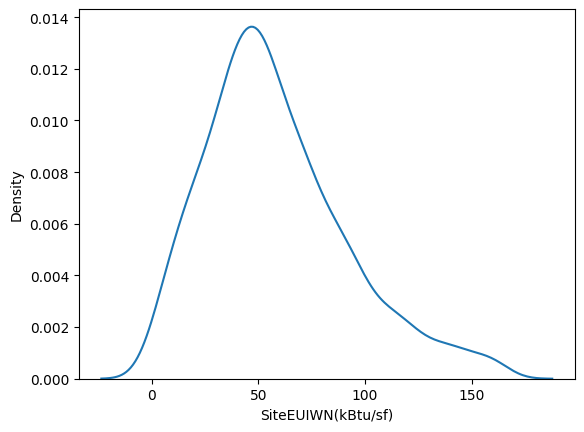

In [27]:
#Etude statistique de la cible 
sns.kdeplot(building_consumption['SiteEUIWN(kBtu/sf)'])

building_consumption['SiteEUIWN(kBtu/sf)'].describe()

In [28]:
#Pour eviter des Low outlier on impose une consomation annuelle en kBtu/sf superieur à 15 
building_consumption=building_consumption[building_consumption['SiteEUIWN(kBtu/sf)']>15]

In [29]:
L_apr, C_apr = building_consumption.shape

print(f" \n Initial {L_avant} lignes et {C_avant} colonnes. \n Actuel {L_apr} lignes et {C_apr} colonnes. \n")

 
 Initial 3376 lignes et 46 colonnes. 
 Actuel 1286 lignes et 22 colonnes. 



<h4> 1.4.3. Localisation</h4> 

<p>On commence par nettoyer de la colonne neighborhood  qui localise le bien dans un quartier. On standardise l'écriture des quartiers et renomme un quartier ayant un ajout inutile.
</p>


In [30]:
building_consumption['Neighborhood'].value_counts()

Neighborhood
DOWNTOWN                  321
GREATER DUWAMISH          276
MAGNOLIA / QUEEN ANNE     118
LAKE UNION                114
EAST                       93
NORTHEAST                  81
NORTHWEST                  63
BALLARD                    47
NORTH                      43
CENTRAL                    36
DELRIDGE                   30
SOUTHEAST                  23
SOUTHWEST                  22
North                       7
Northwest                   3
Central                     3
Ballard                     3
Delridge                    2
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64

In [31]:
#On standardise l'écriture des quartier
building_consumption.loc[:, 'Neighborhood'] = building_consumption['Neighborhood'].str.strip().str.title()

In [32]:
#On renomme un quartier isolé
building_consumption=building_consumption.replace(['Delridge Neighborhoods'], ['Delridge'])
building_consumption['Neighborhood'].value_counts()

Neighborhood
Downtown                 321
Greater Duwamish         276
Magnolia / Queen Anne    118
Lake Union               114
East                      93
Northeast                 81
Northwest                 66
Ballard                   50
North                     50
Central                   39
Delridge                  33
Southeast                 23
Southwest                 22
Name: count, dtype: int64

<p>
Les données les plus précises sont la latitude et la longitude, mais necessite une étude plus approfondi.
    
afin de respecter les delais, nous allons choisir la localité parmis les trois  feature catégories suivante:  
- ZipCode
-  CouncilDistrictCode
-  Neighborhood
</p>

In [33]:

print(f'Il y a {len(building_consumption['ZipCode'].value_counts())} possibilités pour ZipCode')

print(f'Il y a {len(building_consumption['CouncilDistrictCode'].value_counts())} possibilités pour CouncilDistrictCode.')

print(f'Il y a {len(building_consumption['Neighborhood'].value_counts())} possibilités pour Neighborhood.')


Il y a 44 possibilités pour ZipCode
Il y a 7 possibilités pour CouncilDistrictCode.
Il y a 13 possibilités pour Neighborhood.


<p>
En comparaison des autres feature de localisation, la cardinalité de ZipCode est trop élevè et sera donc écartée. 
</p>

<Axes: xlabel='Neighborhood', ylabel='CouncilDistrictCode'>

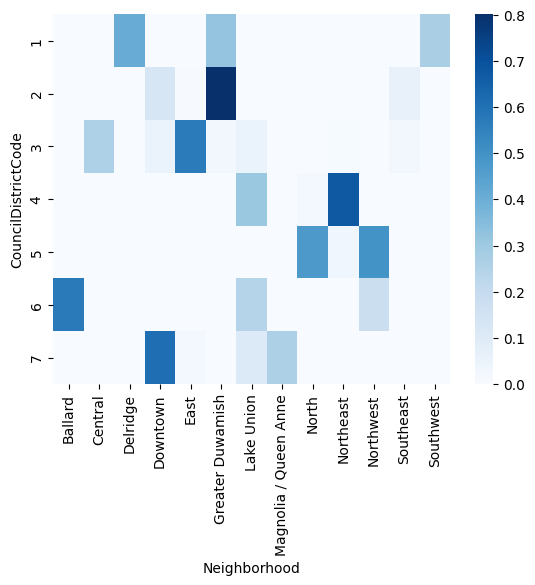

In [34]:
#On observe plusieurs fois le même District pour plusieurs quartiers. La relation n'est pas unique
sns.heatmap(pd.crosstab(building_consumption['CouncilDistrictCode'],building_consumption['Neighborhood'], normalize='index') ,  cmap="Blues" )


<p>
Lorsqu'on compare les districts avec les quartiers, on remarque qu'un district est toujours associée à plusieurs quartier alors que certains quartier sont associé à un seul district. 
    
En première approximation,  il serait donc acceptable de garder Neighborhood.
</p>

In [35]:
a_supp=['CouncilDistrictCode', 'ZipCode', 'Latitude', 'Longitude' ]
building_consumption=building_consumption.drop(a_supp, axis=1)

In [36]:
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1286 entries, 0 to 3375
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   PrimaryPropertyType              1286 non-null   object 
 1   Neighborhood                     1286 non-null   object 
 2   YearBuilt                        1286 non-null   int64  
 3   NumberofBuildings                1286 non-null   float64
 4   NumberofFloors                   1286 non-null   int64  
 5   PropertyGFATotal                 1286 non-null   int64  
 6   PropertyGFAParking               1286 non-null   int64  
 7   PropertyGFABuilding(s)           1286 non-null   int64  
 8   ListOfAllPropertyUseTypes        1286 non-null   object 
 9   LargestPropertyUseType           1282 non-null   object 
 10  LargestPropertyUseTypeGFA        1282 non-null   float64
 11  SecondLargestPropertyUseType     716 non-null    object 
 12  SecondLargestPropertyUseT

<h4> 1.4.4. Année de construction </h4> 

<p>

Les valeurs fournis sont cohérant de 1900 à 2015.
    
</p>

In [37]:
building_consumption['YearBuilt'].describe()

count    1286.000000
mean     1960.667185
std        33.240236
min      1900.000000
25%      1929.000000
50%      1965.000000
75%      1988.000000
max      2015.000000
Name: YearBuilt, dtype: float64

<h4> 1.4.5. Grandeurs physiques des biens immobiliers </h4> 

<p>
En étudiant la correlation entre le nombre de batiments , le nombre d'étage et la supericie totale on remarque peu ou pas de correlation. Nous allons donc garder les trois colonnes. 
    
</p>

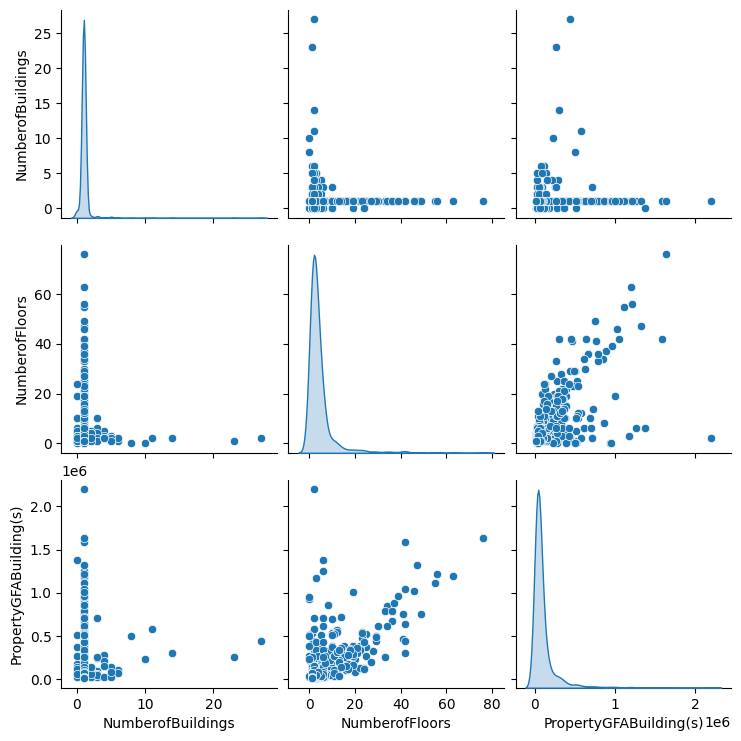

In [38]:
col_quanti=['NumberofBuildings', 'NumberofFloors' ,'PropertyGFABuilding(s)']
sns.pairplot(building_consumption[col_quanti], diag_kind='kde')

In [39]:
building_consumption[col_quanti].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1286 entries, 0 to 3375
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NumberofBuildings       1286 non-null   float64
 1   NumberofFloors          1286 non-null   int64  
 2   PropertyGFABuilding(s)  1286 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 40.2 KB


<h4> 1.4.6. Type de bien </h4> 

<p> On se focalise desormais sur la colonne PrimaryPropertyType qui specifie le type de bien immobilier. 
      
</p>



<h5> 1.4.6.1. Cas multiples: mixed use property :  </h5> 

<p>
Nous allons commencer par nettoyer les "mixed use property'. Ce type de bien est associé à d'autres colonnes:
    
- LargestPropertyUseType      
 
- SecondLargestPropertyUseType

- ThirdLargestPropertyUseType

On remarque la présence de parkings, on suppose que la consomation des parkings est négligeable. 

- Les informations liés aux parkingseront donc retirer



On remarque la présence d'autres batiments non résidentiel   

- Il faudra donc retirer les "Multifamily Housing" . Mais avant de supprimer, la proportions de chaque bien sera determiner afin d'estimer leur consomation. 


En première approximation, les biens multiple seront réorganiser pour obtenir un ensemble de donnée composé exlusivemlebnt de biens unique 
</p>

In [40]:
# Retirer les surfaces négatives ou nulles
building_consumption.loc[building_consumption['ThirdLargestPropertyUseTypeGFA'].round() <= 0, ['ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']] = [np.nan, np.nan]
building_consumption.loc[building_consumption['SecondLargestPropertyUseTypeGFA'].round() <= 0, ['SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA']] = [np.nan, np.nan]


In [41]:
# Fonction qui retire le type_bat d'un df et decale les biens third -> second ou Second -> first si besoin

def multi_type_nettoyage(df, type_bat):
    N_avant=((df['SecondLargestPropertyUseType'].isna()) & (df['ThirdLargestPropertyUseType'].isna())).sum()    

            
    #Modification si le type de batiment non désiré se trouve dans ThirdLargestPropertyUseType
    to_remplace= df['ThirdLargestPropertyUseType'] == type_bat
    df.loc[to_remplace, ['ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']] = [np.nan, np.nan]
  

    #si le type de batiment non désiré se trouve dans SecondLargestPropertyUseType :On remonte les données de Third dans Second
    to_remplace=df['SecondLargestPropertyUseType']==type_bat
    third_vals  = df.loc[to_remplace, ['ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']].to_numpy()
    df.loc[to_remplace,['SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA']]=third_vals
    df.loc[to_remplace, ['ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']] = [np.nan, np.nan]
    
    #si le type de batiment non désiré se trouve dans LargestPropertyUseType  on remonte les données de Second dans Largest 
    #et third dans second
    to_remplace=df['LargestPropertyUseType']==type_bat
    second_vals = df.loc[to_remplace, ['SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA']].to_numpy()
    third_vals  = df.loc[to_remplace, ['ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']].to_numpy()
        
    df.loc[to_remplace,['LargestPropertyUseType' , 'LargestPropertyUseTypeGFA']]= second_vals
    df.loc[to_remplace,['SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA']]=third_vals
    df.loc[to_remplace, ['ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']] = [np.nan, np.nan]

    
    
    N_apres=((df['SecondLargestPropertyUseType'].isna()) & (df['ThirdLargestPropertyUseType'].isna())).sum()    

    print(f'Cette operation à retirer le type {type_bat}. Il y a donc desormais {N_apres-N_avant} type unique en plus')
    
    return

In [42]:
multi_type_nettoyage(building_consumption, 'Parking')


Cette operation à retirer le type Parking. Il y a donc desormais 148 type unique en plus


In [43]:
#Préparation des donné pour determiner le pourcentage de batiment 

cols = ['LargestPropertyUseTypeGFA','SecondLargestPropertyUseTypeGFA','ThirdLargestPropertyUseTypeGFA']

building_consumption[cols] = building_consumption[cols].fillna(0)

# On recalcule la somme totale
building_consumption['PropertyGFABuilding(s)']=(building_consumption['LargestPropertyUseTypeGFA']+building_consumption['SecondLargestPropertyUseTypeGFA']+building_consumption['ThirdLargestPropertyUseTypeGFA'])



building_consumption['LargestPropertyUseTypeGFA']=(100*building_consumption['LargestPropertyUseTypeGFA']/building_consumption['PropertyGFABuilding(s)']).round()
building_consumption['SecondLargestPropertyUseTypeGFA']=(100*building_consumption['SecondLargestPropertyUseTypeGFA']/building_consumption['PropertyGFABuilding(s)']).round()
building_consumption['ThirdLargestPropertyUseTypeGFA']=(100*building_consumption['ThirdLargestPropertyUseTypeGFA']/building_consumption['PropertyGFABuilding(s)']).round()



In [44]:
#building_consumption.loc[building_consumption['SecondLargestPropertyUseType'] == 'Multifamily Housing',:]
building_consumption.loc[440, :]

PrimaryPropertyType                                               Mixed Use Property
Neighborhood                                                              Lake Union
YearBuilt                                                                       1904
NumberofBuildings                                                                1.0
NumberofFloors                                                                     2
PropertyGFATotal                                                               53002
PropertyGFAParking                                                                 0
PropertyGFABuilding(s)                                                       49732.0
ListOfAllPropertyUseTypes          Multifamily Housing, Parking, Restaurant, Reta...
LargestPropertyUseType                                                  Retail Store
LargestPropertyUseTypeGFA                                                       64.0
SecondLargestPropertyUseType                                     

In [45]:

building_consumption.loc[building_consumption['ThirdLargestPropertyUseTypeGFA'].round() <= 0, ['ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']] = [np.nan, np.nan]

building_consumption.loc[building_consumption['SecondLargestPropertyUseTypeGFA'].round() <= 0, ['SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA']] = [np.nan, np.nan]


In [46]:
multi_type_nettoyage(building_consumption, 'Multifamily Housing')


Cette operation à retirer le type Multifamily Housing. Il y a donc desormais 21 type unique en plus


In [47]:

#Selection des batiments à usage unique
To_select=((building_consumption['SecondLargestPropertyUseType'].isna()) & (building_consumption['ThirdLargestPropertyUseType'].isna()) )
building_consumption_unique_usage=building_consumption[To_select].copy()
building_consumption_multiple_usage=building_consumption[~To_select].copy()


In [48]:
building_consumption.shape

(1286, 18)

In [49]:
a_supp=["SecondLargestPropertyUseType", "SecondLargestPropertyUseTypeGFA","ThirdLargestPropertyUseType", "ThirdLargestPropertyUseTypeGFA"]
building_consumption_unique_usage=building_consumption_unique_usage.drop(columns=a_supp)

In [50]:

building_consumption_unique_usage.shape

(800, 14)

In [51]:
building_consumption_multiple_usage.shape

(486, 18)

In [52]:
# On reconstruit un second df à usage unique à partir du df à usage multiple 

#Selection des colonnes
cols_largest = ["LargestPropertyUseType", "LargestPropertyUseTypeGFA"]
cols_second = ["SecondLargestPropertyUseType", "SecondLargestPropertyUseTypeGFA"]
cols_third = ["ThirdLargestPropertyUseType", "ThirdLargestPropertyUseTypeGFA"]

col= [c for c in building_consumption_multiple_usage.columns if c not in cols_largest+ cols_second + cols_third]


building_consumption_unique_usage_1=building_consumption_multiple_usage[col +cols_largest]

building_consumption_unique_usage_2=building_consumption_multiple_usage[col +cols_second].rename(
                                    columns={"SecondLargestPropertyUseType" : "LargestPropertyUseType",
                                             "SecondLargestPropertyUseTypeGFA" : "LargestPropertyUseTypeGFA" }
                                    )

building_consumption_unique_usage_3=building_consumption_multiple_usage[col +cols_third].rename(
                                    columns={"ThirdLargestPropertyUseType" : "LargestPropertyUseType",
                                             "ThirdLargestPropertyUseTypeGFA" : "LargestPropertyUseTypeGFA" }
                                    )

building_consumption_unique_usage_123=pd.concat([building_consumption_unique_usage_1,
                                                 building_consumption_unique_usage_2,
                                                 building_consumption_unique_usage_3] , ignore_index=True)


In [53]:
building_consumption_unique_usage_123=building_consumption_unique_usage_123.dropna(subset=['LargestPropertyUseType'])

In [54]:
# On construit un fichier avec usage unique
building_consumption_unique_usage=pd.concat([building_consumption_unique_usage, building_consumption_unique_usage_123] , ignore_index=True)

In [55]:
# En première approximation, on estime que la répartition energetique suis la même évolution que la surface 

building_consumption_unique_usage['SiteEUIWN(kBtu/sf)']=building_consumption_unique_usage['LargestPropertyUseTypeGFA']*building_consumption_unique_usage['SiteEUIWN(kBtu/sf)']/100


In [56]:
# recalculer la surface avec la proportion
building_consumption_unique_usage['LargestPropertyUseTypeGFA']=building_consumption_unique_usage['LargestPropertyUseTypeGFA']*building_consumption_unique_usage['PropertyGFABuilding(s)']/100

In [57]:
building_consumption.loc[682, :]

PrimaryPropertyType                                         Warehouse
Neighborhood                                         Greater Duwamish
YearBuilt                                                        1969
NumberofBuildings                                                 1.0
NumberofFloors                                                      1
PropertyGFATotal                                                37351
PropertyGFAParking                                                  0
PropertyGFABuilding(s)                                        39120.0
ListOfAllPropertyUseTypes          Non-Refrigerated Warehouse, Office
LargestPropertyUseType                     Non-Refrigerated Warehouse
LargestPropertyUseTypeGFA                                        76.0
SecondLargestPropertyUseType                                   Office
SecondLargestPropertyUseTypeGFA                                  24.0
ThirdLargestPropertyUseType                                       NaN
ThirdLargestProperty

In [58]:
building_consumption_unique_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1909 entries, 0 to 1908
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PrimaryPropertyType        1909 non-null   object 
 1   Neighborhood               1909 non-null   object 
 2   YearBuilt                  1909 non-null   int64  
 3   NumberofBuildings          1909 non-null   float64
 4   NumberofFloors             1909 non-null   int64  
 5   PropertyGFATotal           1909 non-null   int64  
 6   PropertyGFAParking         1909 non-null   int64  
 7   PropertyGFABuilding(s)     1909 non-null   float64
 8   ListOfAllPropertyUseTypes  1909 non-null   object 
 9   LargestPropertyUseType     1905 non-null   object 
 10  LargestPropertyUseTypeGFA  1905 non-null   float64
 11  SiteEUIWN(kBtu/sf)         1905 non-null   float64
 12  Electricity(kBtu)          1909 non-null   float64
 13  NaturalGas(kBtu)           1909 non-null   float

L'information pertinante se trouve désormais sur LargestPropertyUseType.  Nous pouvons désormais supprimer 'PrimaryPropertyType', 'ListOfAllPropertyUseTypes',  'PropertyGFATotal', 'PropertyGFAParking'  et 'PropertyGFABuilding(s)'. 


In [59]:
a_supp=['PrimaryPropertyType','ListOfAllPropertyUseTypes','PropertyGFATotal','PropertyGFAParking', 'PropertyGFABuilding(s)']

building_consumption_unique_usage=building_consumption_unique_usage.drop(a_supp,axis=1)

In [60]:
building_consumption_unique_usage['LargestPropertyUseType'].value_counts()

LargestPropertyUseType
Office                                                  639
Retail Store                                            204
Non-Refrigerated Warehouse                              187
Other                                                   153
Hotel                                                    76
Worship Facility                                         67
Restaurant                                               59
K-12 School                                              57
Medical Office                                           53
Distribution Center                                      51
Other - Entertainment/Public Assembly                    27
Other - Recreation                                       24
College/University                                       19
Fitness Center/Health Club/Gym                           19
Self-Storage Facility                                    19
Senior Care Community                                    17
Social/Meeting Ha

<p>
On remarque encore certaines lignes relative à des batiment résidentiel. Nous allons donc retirer: 

-  Other - Lodging/Residential
-  Residence Hall/Dormitory

</p>


In [61]:
building_consumption_unique_usage=building_consumption_unique_usage[~building_consumption_unique_usage['LargestPropertyUseType'].isin(['Other - Lodging/Residential','Residence Hall/Dormitory'])]

In [62]:
def funct_iqr(df, col_quantitative, col_categorielle, valeur):
    
    filtre=df[col_categorielle] == valeur
    df_par_type=df.loc[filtre,:]
    
    Q1 = df_par_type[col_quantitative].quantile(0.25)
    Q3 = df_par_type[col_quantitative].quantile(0.75)
    IQR = Q3 - Q1
 
    df.loc[(filtre) & ((df[col_quantitative] < Q1 - 1.5 * IQR) | (df[col_quantitative] > Q3 + 1.5 * IQR)) ,:]=np.nan


    return df

In [63]:
for val in building_consumption_unique_usage['LargestPropertyUseType'].unique():
    building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType']==val,:]=funct_iqr(building_consumption_unique_usage, 'SiteEUIWN(kBtu/sf)', 'LargestPropertyUseType', val)


In [64]:
building_consumption_unique_usage=building_consumption_unique_usage.dropna(subset=['LargestPropertyUseType']).reset_index(drop=True)

In [65]:
building_consumption_unique_usage['LargestPropertyUseType'].value_counts()

LargestPropertyUseType
Office                                                  629
Retail Store                                            196
Non-Refrigerated Warehouse                              177
Other                                                   150
Hotel                                                    76
Worship Facility                                         65
K-12 School                                              57
Medical Office                                           53
Restaurant                                               49
Distribution Center                                      48
Other - Entertainment/Public Assembly                    25
Other - Recreation                                       23
College/University                                       18
Self-Storage Facility                                    18
Fitness Center/Health Club/Gym                           18
Senior Care Community                                    17
Social/Meeting Ha

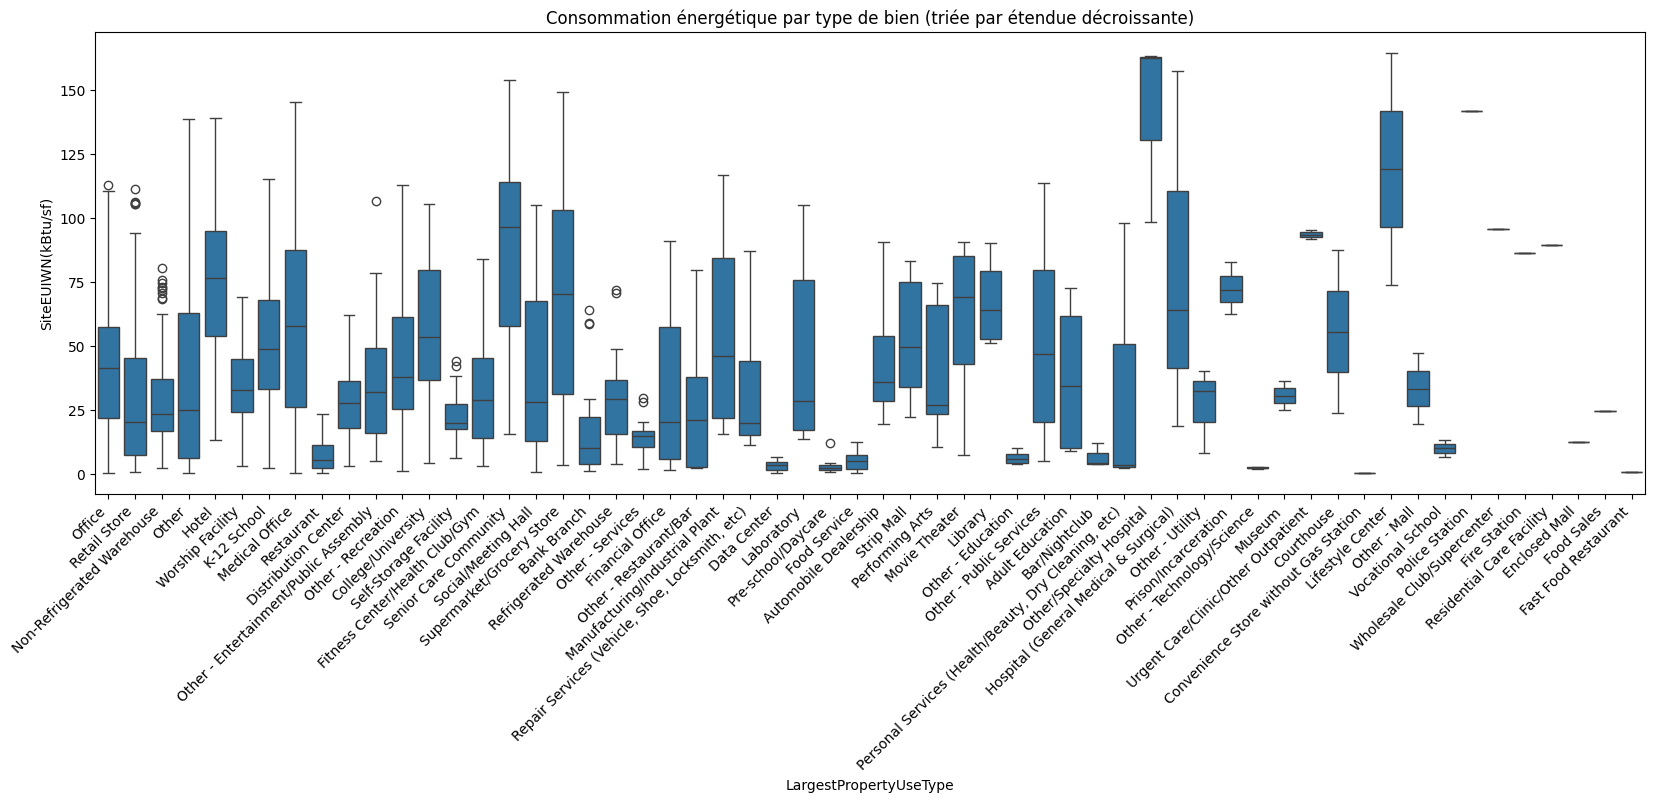

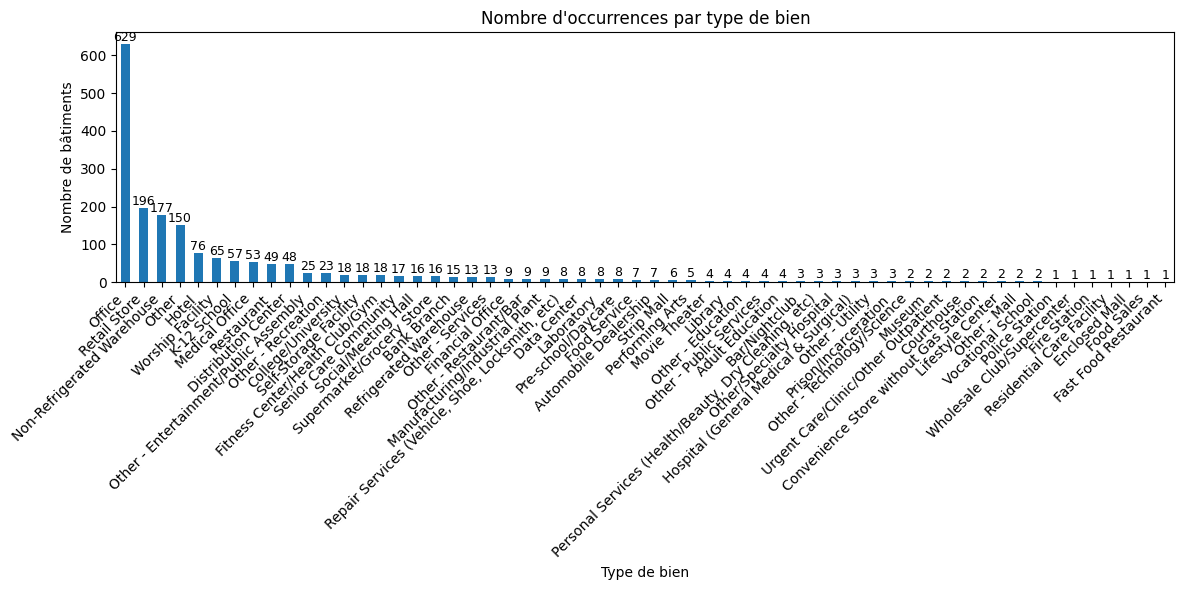

In [66]:
count_par_type = (
    building_consumption_unique_usage['LargestPropertyUseType']
    .value_counts()
)

ordre_types = count_par_type.index.tolist()


plt.figure(figsize=(20,6))
sns.boxplot(
    x='LargestPropertyUseType',
    y='SiteEUIWN(kBtu/sf)',
    data=building_consumption_unique_usage,
    order=ordre_types
)

plt.xticks(rotation=45, ha='right')
plt.title("Consommation énergétique par type de bien (triée par étendue décroissante)")
plt.show()

counts = building_consumption_unique_usage['LargestPropertyUseType'].value_counts()

plt.figure(figsize=(12,6))
ax = counts.plot(kind='bar')

plt.title("Nombre d'occurrences par type de bien")
plt.ylabel("Nombre de bâtiments")
plt.xlabel("Type de bien")
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.tight_layout()
plt.show()


<p>
Il y a trop de catégories, nous allons donc regrouper par catégorie métier. Dans un premier temps on regroupe en utilisant les valeurs dans LargestPropertyUseType. 

Ensuite, les catégorie dificcile à classé seront classé en utilisant la consomation energetique

Il y aura 9 catégories: 
    
1. La catégorie Bureau regroupera: 
 
- 'Office','Bank Branch', 'Financial Office'


2. La catégorie Education regroupera:

- 'K-12 School', 'College/University' ,'Pre-school/Daycare',  'Other - Education'  ,'Adult Education',  'Vocational School'


3. La catégorie Logistique  regroupera:

- 'Non-Refrigerated Warehouse', 'Distribution Center','Self-Storage Facility', 'Refrigerated Warehouse', 'Manufacturing/Industrial Plant'


4. La catégorie Commerce regroupera: 

- 'Retail Store', 'Convenience Store without Gas Station' ,'Food Sales' , 'Supermarket/Grocery Store' ,
- 'Repair Services (Vehicle, Shoe, Locksmith, etc)', 'Personal Services (Health/Beauty, Dry Cleaning, etc)'


5. La catégorie Centre-commercial regroupera: 

- 'Strip Mall' , 'Other - Mall' , 'Lifestyle Center' , 'Wholesale Club/Supercenter' , 'Enclosed Mall' 


6. La catégorie Restauration regroupera:

- 'Restaurant',  'Other - Restaurant/Bar' ,'Food Service' , 'Bar/Nightclub', 'Fast Food Restaurant'
  


7. La catégorie Public regroupera:

-   'Worship Facility' , 'Other - Entertainment/Public Assembly',  'Other - Recreation' , 'Automobile Dealership' ,
-   'Social/Meeting Hall', 'Museum' , 'Library' , 'Performing Arts','Courthouse'  ,'Movie Theater' ,'Prison/Incarceration', 'Police Station' 


8. La catégorie Soins regroupera: 

- 'Senior Care Community' , 'Other/Specialty Hospital' , 'Hospital (General Medical & Surgical)' ,
-  'Urgent Care/Clinic/Other Outpatient' , 'Residential Care Facility', 'Laboratory' ,'Medical Office','Fitness Center/Health Club/Gym'


9. La catégorie Hotel qui contient uniquement :

- Hotel

  
10. La catégorie Autres regroupera:

- 'Other','Other - Services', 'Other - Public Services','Other - Utility' , 'Other - Technology/Science' , 'Fire Station' , 'Data Center'



</p>


In [67]:
# Strategie de regroupement 


# Nom_in= ['Office','Bank Branch', 'Financial Office'] 
# Nom_in= ['K-12 School', 'College/University' ,'Pre-school/Daycare',  'Other - Education'  ,'Adult Education',  'Vocational School']
# Nom_in= ['Non-Refrigerated Warehouse', 'Distribution Center','Self-Storage Facility', 'Refrigerated Warehouse', 'Manufacturing/Industrial Plant' ]
# Nom_in= ['Retail Store', 'Supermarket/Grocery Store' ,'Convenience Store without Gas Station' ,'Food Sales' ,
#           'Repair Services (Vehicle, Shoe, Locksmith, etc)', 'Personal Services (Health/Beauty, Dry Cleaning, etc)'
#         ]

# Nom_in= ['Strip Mall' , 'Other - Mall' , 'Lifestyle Center' , 'Wholesale Club/Supercenter' , 'Enclosed Mall']
# Nom_in= ['Restaurant',  'Other - Restaurant/Bar' ,'Food Service' , 'Bar/Nightclub', 'Fast Food Restaurant']

# Nom_in= [ 'Worship Facility' , 'Other - Entertainment/Public Assembly',  'Other - Recreation' , 'Automobile Dealership' ,
# 'Social/Meeting Hall', 'Museum' , 'Library' , 'Performing Arts']
# Nom_in= ['Other','Other - Services', 'Other - Public Services','Other - Utility' , 'Other - Technology/Science']

# Nom_in= [ 'Senior Care Community' , 'Other/Specialty Hospital' , 'Hospital (General Medical & Surgical)' ,
#          'Urgent Care/Clinic/Other Outpatient' , 'Residential Care Facility', 'Medical Office','Fitness Center/Health Club/Gym', 'Laboratory']


# building00=building_consumption_unique_usage[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in)]



# count_par_type = (
#     building00['LargestPropertyUseType']
#     .value_counts()
# )

# ordre_types = count_par_type.index.tolist()



# plt.figure(figsize=(20,6))
# sns.boxplot(
#     x='LargestPropertyUseType',
#     y='SiteEUIWN(kBtu/sf)',
#     data=building00,
#     order=ordre_types
# )

# plt.xticks(rotation=45, ha='right')
# plt.title("Consommation énergétique par type de bien (triée par étendue décroissante)")
# plt.show()


# counts = building00['LargestPropertyUseType'].value_counts()

# plt.figure(figsize=(12,6))
# ax = counts.plot(kind='bar')

# plt.title("Nombre d'occurrences par type de bien")
# plt.ylabel("Nombre de bâtiments")
# plt.xlabel("Type de bien")
# plt.xticks(rotation=45, ha='right')

# # Ajouter les valeurs au-dessus des barres
# for p in ax.patches:
#     ax.annotate(
#         str(int(p.get_height())),
#         (p.get_x() + p.get_width() / 2, p.get_height()),
#         ha='center',
#         va='bottom',
#         fontsize=9
#     )

# plt.tight_layout()
# plt.show()



In [68]:
Nom_in= ['Office','Bank Branch', 'Financial Office']
Nom_out='Bureau'

building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in), 'LargestPropertyUseType'] = Nom_out


In [69]:
Nom_in= ['K-12 School', 'College/University' ,'Pre-school/Daycare',  'Other - Education'  ,'Adult Education',  'Vocational School']
Nom_out='Education'

building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in), 'LargestPropertyUseType'] = Nom_out


In [70]:
Nom_in= ['Non-Refrigerated Warehouse', 'Distribution Center','Self-Storage Facility', 'Refrigerated Warehouse', 'Manufacturing/Industrial Plant' ]
Nom_out='Logistique'

building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in), 'LargestPropertyUseType'] = Nom_out


In [71]:
Nom_in= ['Retail Store', 'Convenience Store without Gas Station' ,'Food Sales' , 'Supermarket/Grocery Store' ,
          'Repair Services (Vehicle, Shoe, Locksmith, etc)', 'Personal Services (Health/Beauty, Dry Cleaning, etc)'
        ]
Nom_out='Commerce'

building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in), 'LargestPropertyUseType'] = Nom_out


In [72]:
Nom_in= [ 'Strip Mall' , 'Other - Mall' , 'Lifestyle Center' , 'Wholesale Club/Supercenter' , 'Enclosed Mall' 
        ]
Nom_out='Mall'

building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in), 'LargestPropertyUseType'] = Nom_out


In [73]:
Nom_in= [ 'Restaurant',  'Other - Restaurant/Bar' ,'Food Service' , 'Bar/Nightclub', 'Fast Food Restaurant']
Nom_out='Restauration'

building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in), 'LargestPropertyUseType'] = Nom_out


In [74]:
Nom_in= [ 'Worship Facility' , 'Other - Entertainment/Public Assembly',  'Other - Recreation' , 'Automobile Dealership' ,
'Social/Meeting Hall', 'Museum' , 'Library' , 'Performing Arts','Courthouse'  ,'Movie Theater' ,'Prison/Incarceration', 'Police Station' ] 
Nom_out='Public'

building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in), 'LargestPropertyUseType'] = Nom_out


In [75]:
Nom_in= [ 'Senior Care Community' , 'Other/Specialty Hospital' , 'Hospital (General Medical & Surgical)' ,
         'Urgent Care/Clinic/Other Outpatient' , 'Residential Care Facility', 'Laboratory' ,'Medical Office','Fitness Center/Health Club/Gym']
Nom_out='Soins'

building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in), 'LargestPropertyUseType'] = Nom_out


In [76]:
Nom_in= ['Other','Other - Services', 'Other - Public Services','Other - Utility' , 'Other - Technology/Science' , 'Fire Station' , 'Data Center']
Nom_out='Autres'

building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType'].isin(Nom_in), 'LargestPropertyUseType'] = Nom_out


In [77]:
building_consumption_unique_usage['LargestPropertyUseType'].value_counts()



LargestPropertyUseType
Bureau          653
Logistique      265
Commerce        226
Autres          181
Public          157
Soins           105
Education        93
Hotel            76
Restauration     69
Mall             12
Name: count, dtype: int64

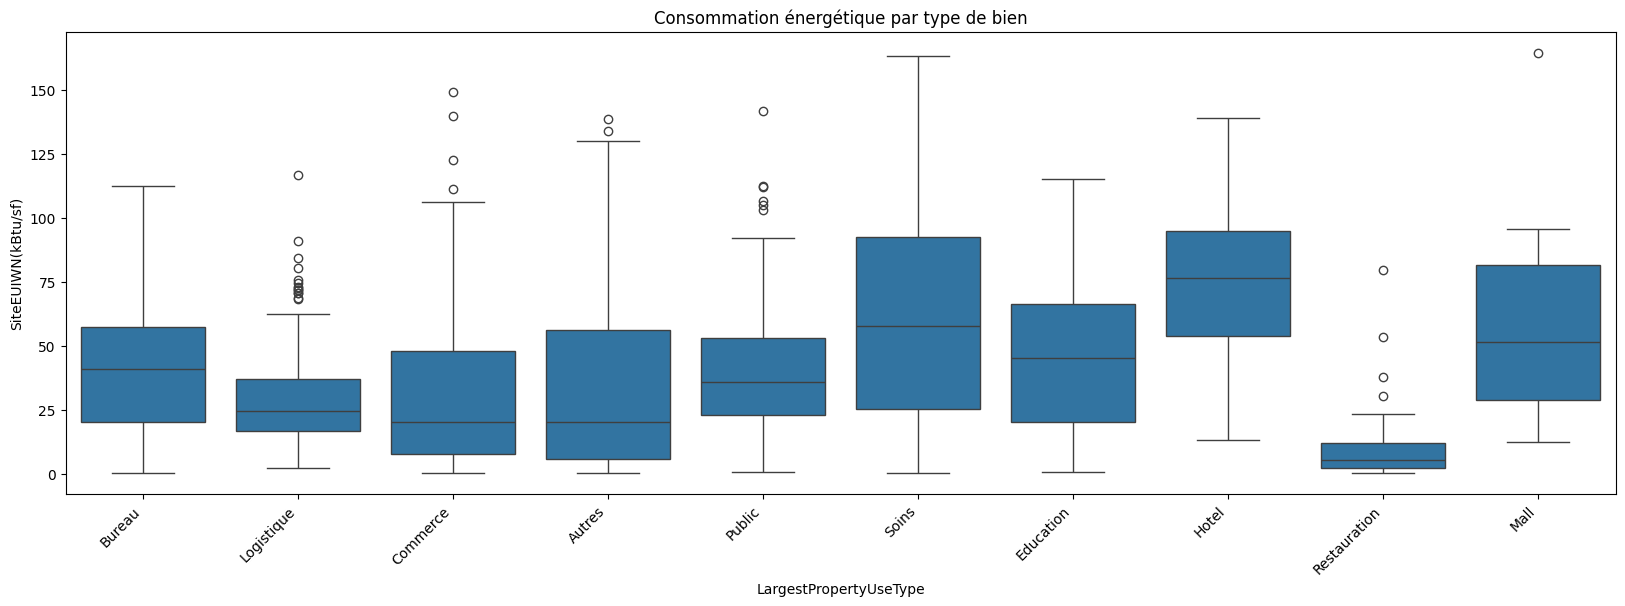

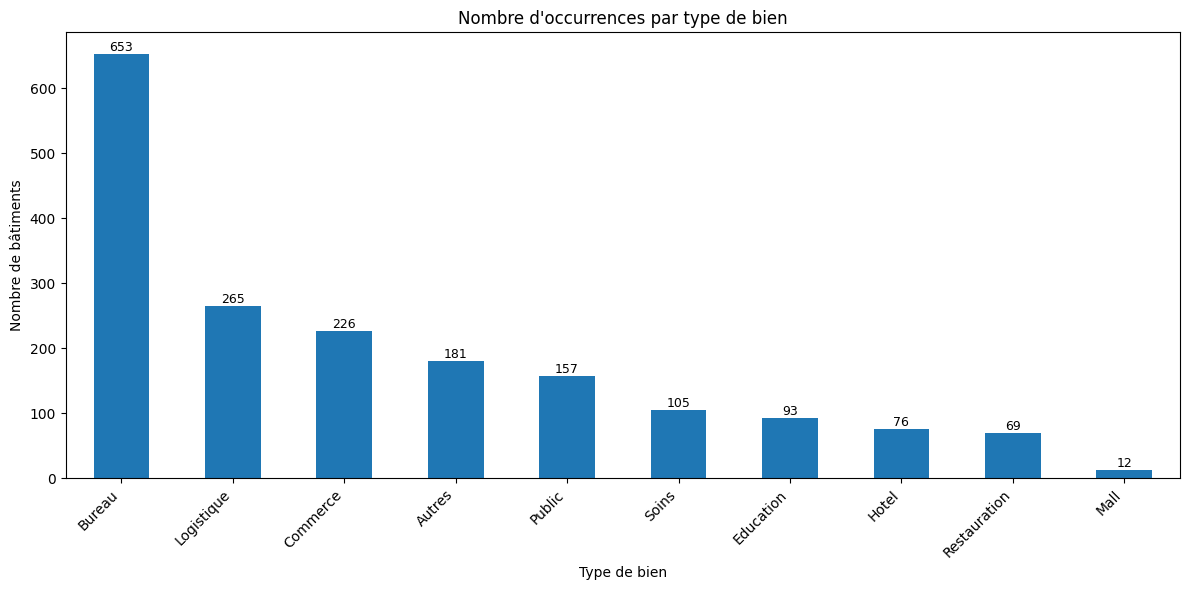

In [78]:
count_par_type = (
    building_consumption_unique_usage['LargestPropertyUseType']
    .value_counts()
)

ordre_types = count_par_type.index.tolist()


plt.figure(figsize=(20,6))
sns.boxplot(
    x='LargestPropertyUseType',
    y='SiteEUIWN(kBtu/sf)',
    data=building_consumption_unique_usage,
    order=ordre_types
)

plt.xticks(rotation=45, ha='right')
plt.title("Consommation énergétique par type de bien")
plt.show()

counts = building_consumption_unique_usage['LargestPropertyUseType'].value_counts()

plt.figure(figsize=(12,6))
ax = counts.plot(kind='bar')

plt.title("Nombre d'occurrences par type de bien")
plt.ylabel("Nombre de bâtiments")
plt.xlabel("Type de bien")
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.tight_layout()
plt.show()

<h5> 1.4.6.2. Etude de la distribution de la consommation énergetique en fonction du type de bien :  </h5> 

<p>
Précédement nous avons utilisé une boîte à moustaches pour observer la distribution de la consommation énergétique pour chaque type de bien. Et on peut remarque la présence d’outliers. Nous allons donc réaliser une procédure pour retirer ces valeurs.
</p>


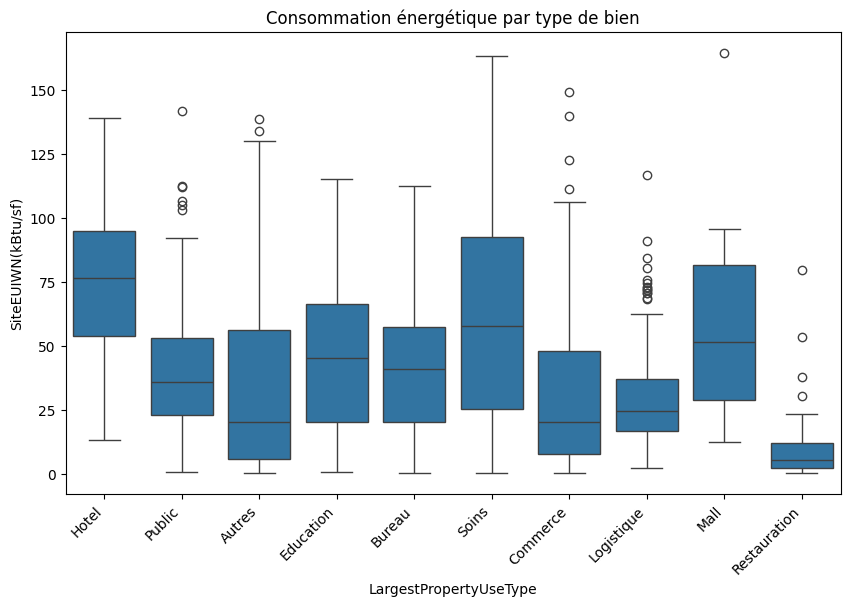

In [79]:
plt.figure(figsize=(10,6))
sns.boxplot(x='LargestPropertyUseType', y='SiteEUIWN(kBtu/sf)', data=building_consumption_unique_usage)
plt.xticks(rotation=45, ha='right')  
plt.title("Consommation énergétique par type de bien")
plt.show()

In [80]:
for val in building_consumption_unique_usage['LargestPropertyUseType'].unique():
    building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType']==val,:]=funct_iqr(building_consumption_unique_usage, 'SiteEUIWN(kBtu/sf)', 'LargestPropertyUseType', val)


In [81]:
building_consumption_unique_usage=building_consumption_unique_usage.dropna(subset=['LargestPropertyUseType']).reset_index(drop=True)

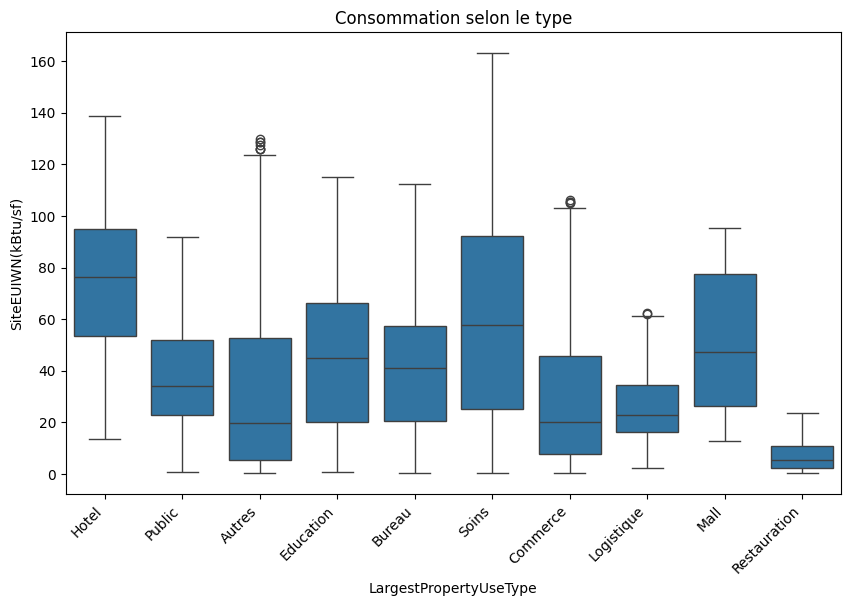

In [82]:
plt.figure(figsize=(10,6))
sns.boxplot(x='LargestPropertyUseType', y='SiteEUIWN(kBtu/sf)', data=building_consumption_unique_usage)
plt.xticks(rotation=45, ha='right')  
plt.title("Consommation selon le type")
plt.show()

On regarde aussi la distribution surfacique des différantes catégorie, et on observe d'autres outliers à retirer

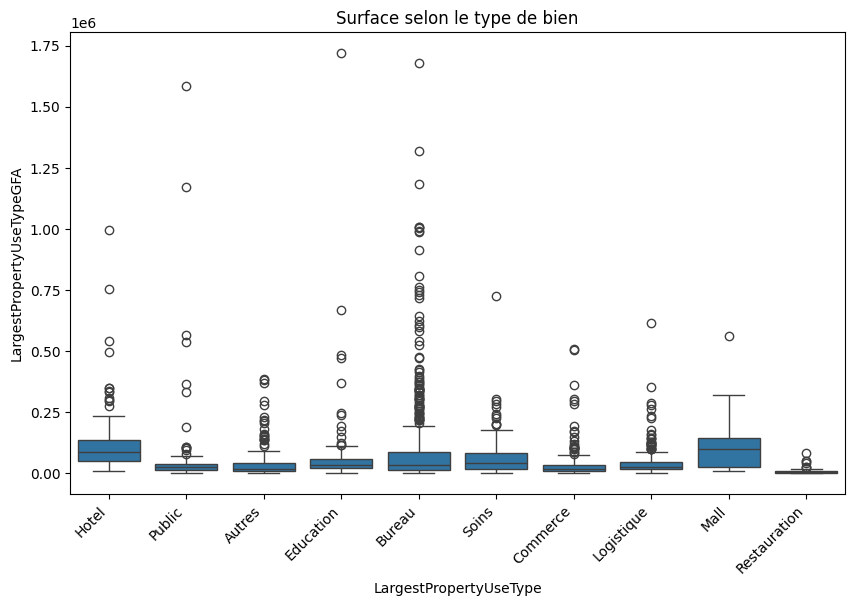

In [83]:
plt.figure(figsize=(10,6))
sns.boxplot(x='LargestPropertyUseType', y='LargestPropertyUseTypeGFA', data=building_consumption_unique_usage)
plt.xticks(rotation=45, ha='right')  
plt.title("Surface selon le type de bien")
plt.show()


In [84]:

for type_value in building_consumption_unique_usage['LargestPropertyUseType'].unique():
    building_consumption_unique_usage.loc[building_consumption_unique_usage['LargestPropertyUseType']==type_value,:]=funct_iqr(building_consumption_unique_usage,'LargestPropertyUseTypeGFA', 'LargestPropertyUseType', type_value)


In [85]:
building_consumption_unique_usage['LargestPropertyUseType'].value_counts()

LargestPropertyUseType
Bureau          580
Logistique      224
Commerce        199
Autres          159
Public          138
Soins            94
Education        80
Hotel            64
Restauration     58
Mall             10
Name: count, dtype: int64

In [86]:
building_consumption_unique_usage=building_consumption_unique_usage.dropna(subset=['LargestPropertyUseType']).reset_index(drop=True)

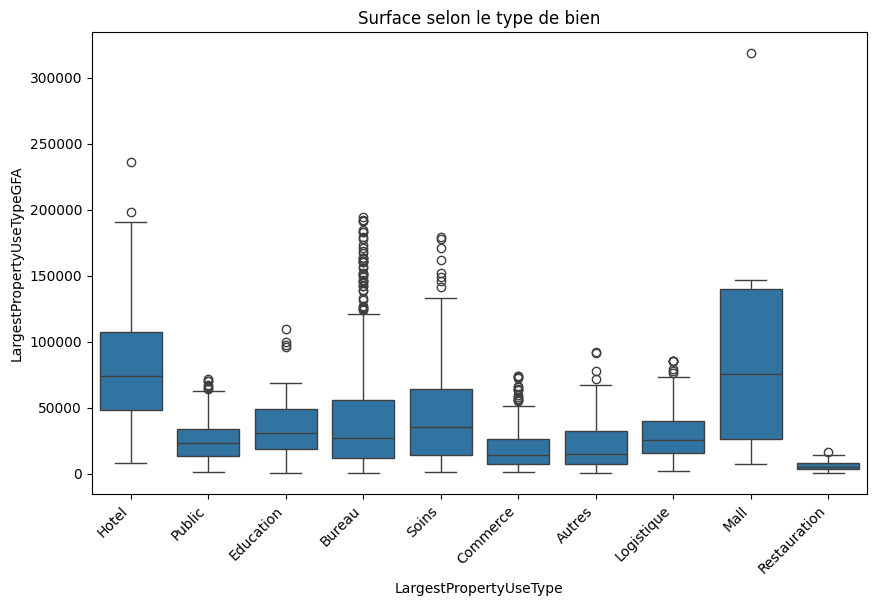

In [87]:
plt.figure(figsize=(10,6))
sns.boxplot(x='LargestPropertyUseType', y='LargestPropertyUseTypeGFA', data=building_consumption_unique_usage)
plt.xticks(rotation=45, ha='right')  
plt.title("Surface selon le type de bien")
plt.show()

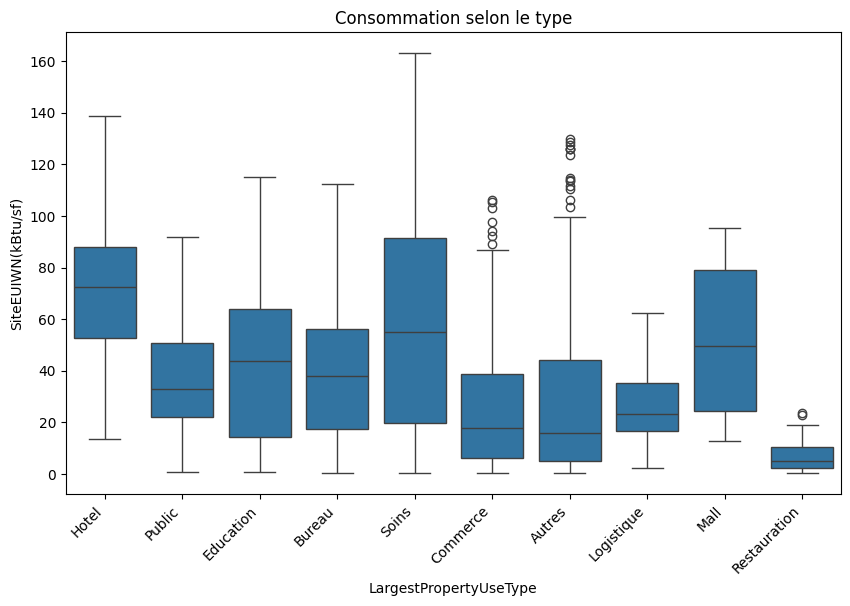

In [88]:
plt.figure(figsize=(10,6))
sns.boxplot(x='LargestPropertyUseType', y='SiteEUIWN(kBtu/sf)', data=building_consumption_unique_usage)
plt.xticks(rotation=45, ha='right')  
plt.title("Consommation selon le type")
plt.show()

In [89]:
building_consumption_unique_usage=building_consumption_unique_usage.rename(
    columns={'LargestPropertyUseType':'PropertyUseType'
            ,'LargestPropertyUseTypeGFA':'PropertyUseTypeGFA'}
)

In [90]:
building_consumption_unique_usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Neighborhood        1606 non-null   object 
 1   YearBuilt           1606 non-null   float64
 2   NumberofBuildings   1606 non-null   float64
 3   NumberofFloors      1606 non-null   float64
 4   PropertyUseType     1606 non-null   object 
 5   PropertyUseTypeGFA  1606 non-null   float64
 6   SiteEUIWN(kBtu/sf)  1606 non-null   float64
 7   Electricity(kBtu)   1606 non-null   float64
 8   NaturalGas(kBtu)    1606 non-null   float64
dtypes: float64(7), object(2)
memory usage: 113.1+ KB


In [91]:
L_apr, C_apr = building_consumption_unique_usage.shape

print(f" \n Initial {L_avant} lignes et {C_avant} colonnes. \n Actuel {L_apr} lignes et {C_apr} colonnes. \n")

 
 Initial 3376 lignes et 46 colonnes. 
 Actuel 1606 lignes et 9 colonnes. 



<h2> 2. Feature Engineering </h2> 

--- 

<p> A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

</p> 



<h3> 2.1. Binarisation des colonnes Electricité et gaz</h3> 

<p>
Le type de consomation est une donnée importante pour prédire la consomation. Mais afin d'éviter le data Leakage on transforme ces collone pour indiquer uniquement le type de consomation utilisé et non pas les valeurs.   

</p>


In [92]:
building_consumption_unique_usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Neighborhood        1606 non-null   object 
 1   YearBuilt           1606 non-null   float64
 2   NumberofBuildings   1606 non-null   float64
 3   NumberofFloors      1606 non-null   float64
 4   PropertyUseType     1606 non-null   object 
 5   PropertyUseTypeGFA  1606 non-null   float64
 6   SiteEUIWN(kBtu/sf)  1606 non-null   float64
 7   Electricity(kBtu)   1606 non-null   float64
 8   NaturalGas(kBtu)    1606 non-null   float64
dtypes: float64(7), object(2)
memory usage: 113.1+ KB


In [93]:
building_consumption_unique_usage.loc[building_consumption_unique_usage['Electricity(kBtu)']!=0,'Electricity(kBtu)']=1
building_consumption_unique_usage.loc[building_consumption_unique_usage['NaturalGas(kBtu)']!=0,'NaturalGas(kBtu)']=1

In [94]:
print(f'{building_consumption_unique_usage['Electricity(kBtu)'].value_counts()}')

print(f'{building_consumption_unique_usage['NaturalGas(kBtu)'].value_counts()}')

Electricity(kBtu)
1.0    1606
Name: count, dtype: int64
NaturalGas(kBtu)
1.0    1149
0.0     457
Name: count, dtype: int64


Tous les batiments ont l'electricité cette feature n'apporte pas de differentiation. Elle sera donc supprimé



In [95]:
building_consumption_unique_usage = building_consumption_unique_usage.drop(columns=['Electricity(kBtu)'])

In [96]:
building_consumption_unique_usage.loc[10,:]

Neighborhood           Downtown
YearBuilt                2001.0
NumberofBuildings           1.0
NumberofFloors             10.0
PropertyUseType           Hotel
PropertyUseTypeGFA     128909.0
SiteEUIWN(kBtu/sf)    86.699997
NaturalGas(kBtu)            1.0
Name: 10, dtype: object

<h3> 2.2. Numerisation du Quartier avec OneHotEncoder</h3> 

<p>
 

</p>


In [97]:
building_consumption_unique_usage = pd.get_dummies(building_consumption_unique_usage, columns=['Neighborhood'], dtype='float64')

<h3> 2.3. Numerisation du PrimaryPropertyType avec OneHotEncoder</h3> 

<p>
 

</p>


In [98]:
building_consumption_unique_usage = pd.get_dummies(building_consumption_unique_usage, columns=['PropertyUseType'], dtype='float64')

In [99]:
building_consumption_unique_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   YearBuilt                           1606 non-null   float64
 1   NumberofBuildings                   1606 non-null   float64
 2   NumberofFloors                      1606 non-null   float64
 3   PropertyUseTypeGFA                  1606 non-null   float64
 4   SiteEUIWN(kBtu/sf)                  1606 non-null   float64
 5   NaturalGas(kBtu)                    1606 non-null   float64
 6   Neighborhood_Ballard                1606 non-null   float64
 7   Neighborhood_Central                1606 non-null   float64
 8   Neighborhood_Delridge               1606 non-null   float64
 9   Neighborhood_Downtown               1606 non-null   float64
 10  Neighborhood_East                   1606 non-null   float64
 11  Neighborhood_Greater Duwamish       1606 no


<p> 
    
- Séparation  votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).    

</p> 



In [100]:
X=building_consumption_unique_usage.drop(columns='SiteEUIWN(kBtu/sf)')

y=building_consumption_unique_usage['SiteEUIWN(kBtu/sf)']

In [101]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   YearBuilt                           1606 non-null   float64
 1   NumberofBuildings                   1606 non-null   float64
 2   NumberofFloors                      1606 non-null   float64
 3   PropertyUseTypeGFA                  1606 non-null   float64
 4   NaturalGas(kBtu)                    1606 non-null   float64
 5   Neighborhood_Ballard                1606 non-null   float64
 6   Neighborhood_Central                1606 non-null   float64
 7   Neighborhood_Delridge               1606 non-null   float64
 8   Neighborhood_Downtown               1606 non-null   float64
 9   Neighborhood_East                   1606 non-null   float64
 10  Neighborhood_Greater Duwamish       1606 non-null   float64
 11  Neighborhood_Lake Union             1606 no

<h2> 3. Comparaison de différents modèles supervisés </h2> 

--- 

<p> A réaliser :
    
- Pour chaque algorithme que vous allez tester, vous devez :

    - Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    - Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    - Entrainer le modèle sur le jeu de Train
    - Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    - Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    - Interpréter les résultats pour juger de la fiabilité de l'algorithme.

- Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
- Déterminer le modèle le plus performant parmi ceux testés.

    
</p> 


In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

In [103]:
def Calcul_metrique_du_model_par_cv(model, X_train, y_train, graine, n_splits):

    kf = KFold(n_splits, shuffle=True, random_state=graine)
        
        
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    
    cv_R2 =  cross_validate(pipe, X_train, y_train, cv=kf, scoring='r2', return_train_score=True)
    cv_mse = cross_validate(pipe, X_train, y_train, cv=kf, scoring='neg_mean_squared_error', return_train_score=True)

    R2_test = cv_R2['test_score']
    R2_train = cv_R2['train_score']

    print(f"Moyenne R2 test: {np.mean(R2_test):.4f} et Moyenne R2 train: {np.mean(R2_train):.4f}")
  #  print(f"Étendue R2 test: {R2_test.max() - R2_test.min():.4f} et Étendue R2 train: {R2_train.max() - R2_train.min():.4f}")


    RMSE_test = np.sqrt(-cv_mse['test_score'])
    RMSE_train = np.sqrt(-cv_mse['train_score'])

    print(f"Moyenne RMSE test: {np.mean(RMSE_test):.4f} et Moyenne RMSE train: {np.mean(RMSE_train):.4f}")
#    print(f"Étendue RMSE test: {RMSE_test.max() - RMSE_test.min():.4f} et Étendue RMSE train: {RMSE_train.max() - RMSE_train.min():.4f}")


    
    metrics = {'RMSE-test': np.sqrt(-cv_mse['test_score']), 'RMSE-train': np.sqrt(-cv_mse['train_score'])}
    
    plt.figure(figsize=(8,5))
    for i, (metric_name, scores) in enumerate(metrics.items()):
        plt.scatter(range(1, n_splits+1), scores, label=metric_name, s=80)
    plt.xlabel("Fold")
    plt.ylabel("Score")
    plt.title("Scores par fold")
    plt.legend()
    plt.show()


    metrics = {'R2-Test': cv_R2['test_score'],'R2-Train': cv_R2['train_score'] }
    
    plt.figure(figsize=(8,5))
    for i, (metric_name, scores) in enumerate(metrics.items()):
        plt.scatter(range(1, n_splits+1), scores, label=metric_name, s=80)
    plt.xlabel("Fold")
    plt.ylabel("Score")
    plt.title("Scores par fold ")
    plt.legend()
    plt.show()
    
    return 

In [104]:
def Calcul_metrique_du_model_par_train_test(model, X_train, y_train, X_test, y_test,graine=50):

    model.random_state = graine

    model.fit(X_train, y_train)
        
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'R2 est : {round(r2,2)} ')
    print(f'RMSE est :{np.sqrt(mse)} ')

    return 
    
    

In [105]:
n_fold=5
graine=50

<h3 > 3.1. Regression Lineaire </h3> 


<p>
    
</p> 


Moyenne R2 test: 0.3304 et Moyenne R2 train: 0.3725
Moyenne RMSE test: 23.4574 et Moyenne RMSE train: 22.8676


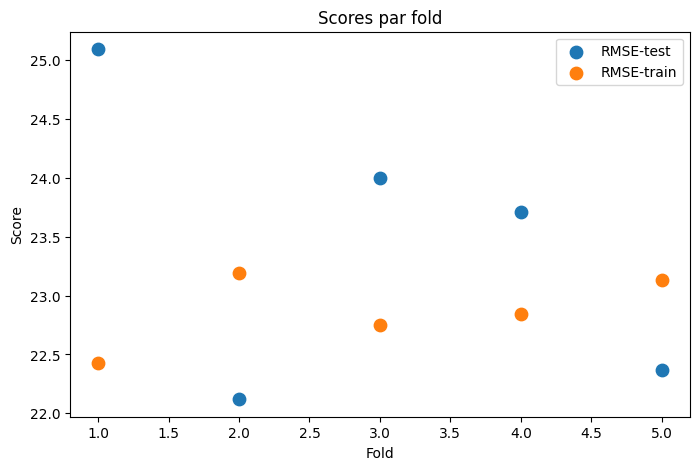

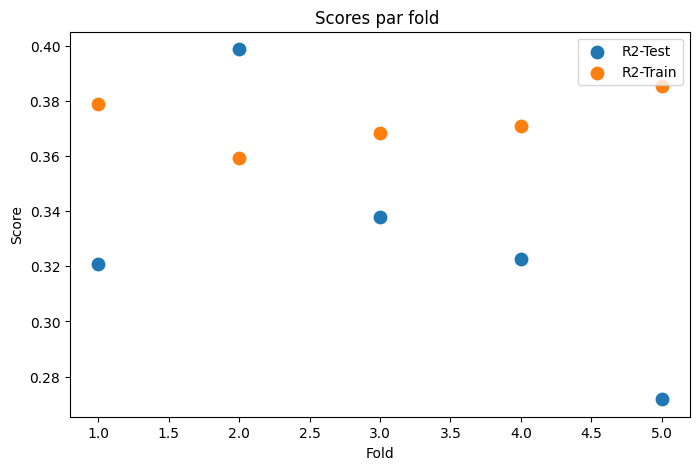

In [106]:
Calcul_metrique_du_model_par_cv(LinearRegression(),X_train,y_train,graine,n_fold)

In [107]:
Calcul_metrique_du_model_par_train_test(LinearRegression(), X_train, y_train, X_test, y_test,graine)

R2 est : 0.32 
RMSE est :24.05912611522778 


<h3> 3.2. Foret aléatoire </h3> 


<p>
    
</p> 


Moyenne R2 test: 0.4840 et Moyenne R2 train: 0.9312
Moyenne RMSE test: 20.5835 et Moyenne RMSE train: 7.5714


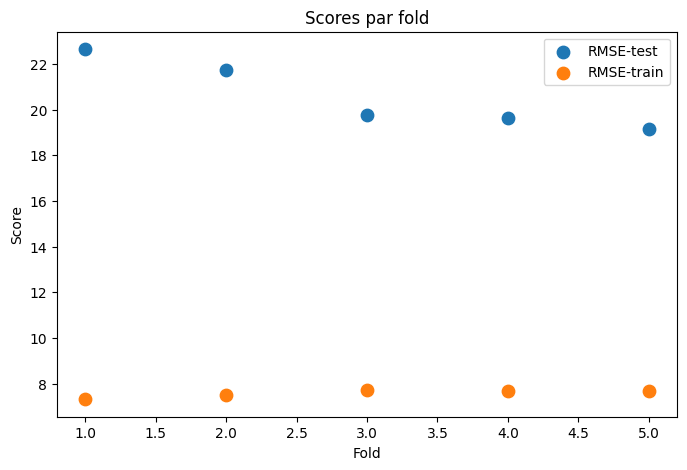

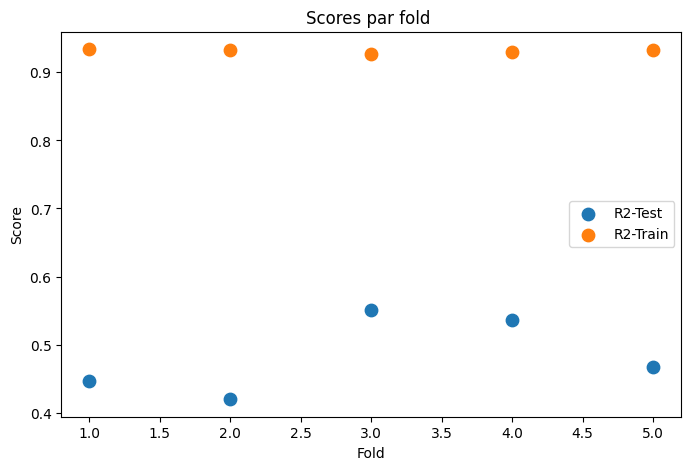

In [108]:
Calcul_metrique_du_model_par_cv(RandomForestRegressor(random_state=graine),X_train,y_train,graine,n_fold)

In [109]:
Calcul_metrique_du_model_par_train_test(RandomForestRegressor(random_state=graine), X_train, y_train, X_test, y_test,graine)

R2 est : 0.43 
RMSE est :21.90033251698675 


<h3> 3.3. SVR</h3> 


<p>
    
</p> 


Moyenne R2 test: 0.1634 et Moyenne R2 train: 0.1998
Moyenne RMSE test: 26.2679 et Moyenne RMSE train: 25.8234


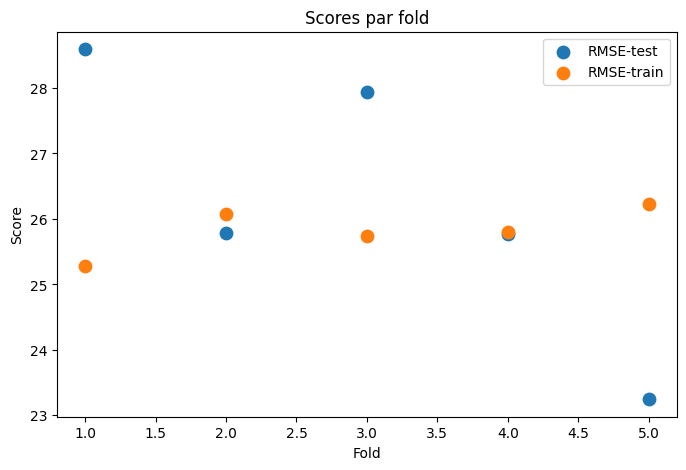

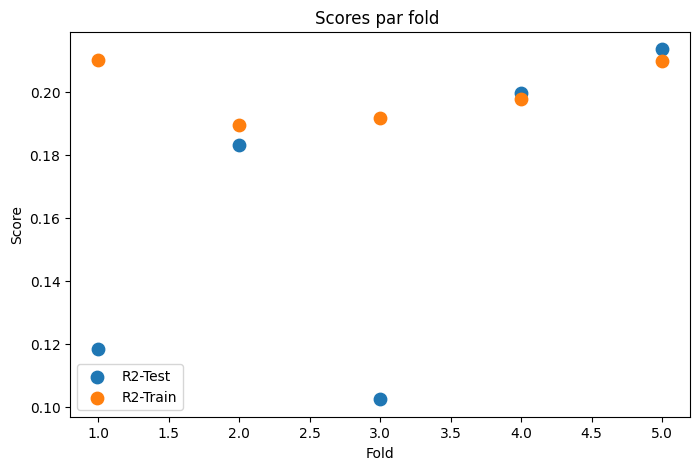

In [110]:
Calcul_metrique_du_model_par_cv(SVR(),X_train,y_train,graine,n_fold)

In [111]:
Calcul_metrique_du_model_par_train_test(SVR(), X_train, y_train, X_test, y_test,graine)

R2 est : 0.36 
RMSE est :23.31239995352778 


<h2> 4. Optimisation et interprétation du modèle </h2> 

--- 
<p> A réaliser :

    - Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
    - Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 
</p> 


$\quad \text{} $

<h3> 4.1. GridSearch </h3> 



In [112]:
model=RandomForestRegressor(random_state=graine)


##########################
# Version court centré sur le best le best directement
##########################
param_grid = {
    'n_estimators': np.arange(50, 101,50 ),
    'max_depth': np.arange(10, 21,10), 
    'min_samples_split': np.arange(2, 5),
    'min_samples_leaf': np.arange(2, 5),
}



#####################
# Version long pour la recherche du best
##########################
# param_grid = {
#     'n_estimators': np.arange(20, 201,20 ),
#     'max_depth': np.arange(10, 21), 
#     'min_samples_split': np.arange(2, 15),
#     'min_samples_leaf': np.arange(2, 15),
# }


kf = KFold(n_splits=n_fold, shuffle=True, random_state=graine)

grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=kf,scoring='r2',n_jobs=-1)


grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV (R2) :", grid.best_score_)



best_model_train = grid.best_estimator_
y_pred = best_model_train.predict(X_train)

print("R2 sur train :", r2_score(y_train, y_pred))
print("RMSE sur train :", np.sqrt(mean_squared_error(y_train, y_pred)))


best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("R2 sur test :", r2_score(y_test, y_pred))
print("RMSE sur test :", np.sqrt(mean_squared_error(y_test, y_pred)))





KeyboardInterrupt: 

<h3> 4.2 Feature importance   </h3> 



In [ ]:

def feature_importances(model, X):

    importances = model.feature_importances_
    
    feature_names = X.columns 
    
    feat_imp_df = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False)
    
    # Affichage
    plt.figure(figsize=(8, 8))
    plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
    plt.gca().invert_yaxis()
    plt.title("Feature Importances")
    plt.xlabel("Importance")
    plt.show()
    
    return

In [ ]:
feature_importances(best_model, X_train)
